In [2]:
# Importing libraries
import pandas as pd
import numpy as np

%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree

from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler 
from sklearn import metrics

In [14]:
# Read dataset 
df = pd.read_csv('heart_2020_cleaned.csv')
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

In [16]:
df.nunique()

HeartDisease           2
BMI                 3604
Smoking                2
AlcoholDrinking        2
Stroke                 2
PhysicalHealth        31
MentalHealth          31
DiffWalking            2
Sex                    2
AgeCategory           13
Race                   6
Diabetic               4
PhysicalActivity       2
GenHealth              5
SleepTime             24
Asthma                 2
KidneyDisease          2
SkinCancer             2
dtype: int64

In [21]:
df = df.replace({'Yes':1, 'No':0, 'Male':1, 'Female':0, 'No, borderline diabetes':0, 'Yes (during pregnancy)':1})
df = df.infer_objects(copy=False)

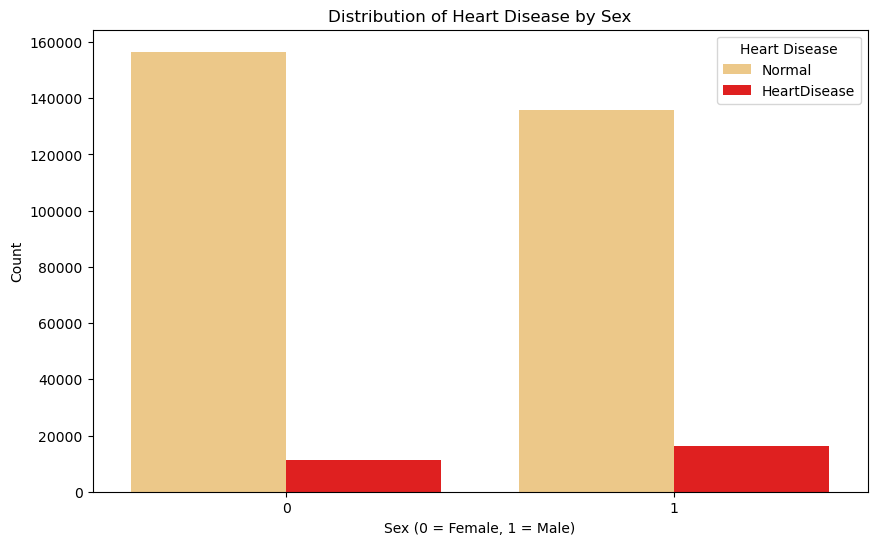

In [25]:
plt.figure(figsize=(10, 6))
# Using a countplot is more appropriate for categorical data like Sex
sns.countplot(data=df, x='Sex', hue='HeartDisease', palette=['#fccc79', 'red'])
plt.title('Distribution of Heart Disease by Sex')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.ylabel('Count')
plt.legend(title='Heart Disease', labels=['Normal', 'HeartDisease'])
plt.show()

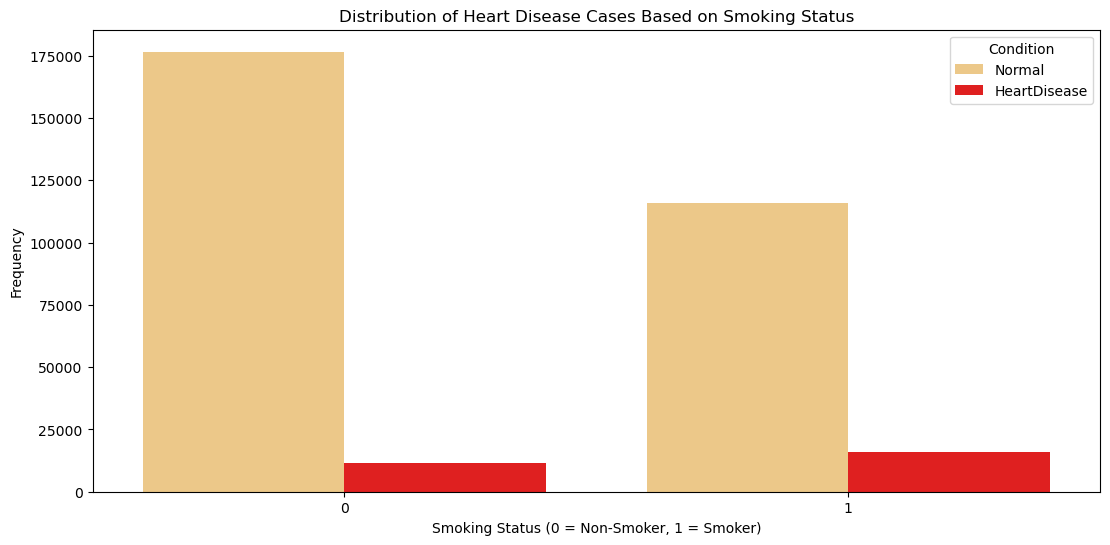

In [29]:
# Set the figure size
plt.figure(figsize=(13, 6))

# Use countplot for categorical data
# hue='HeartDisease' automatically splits the bars by the outcome
sns.countplot(data=df, x='Smoking', hue='HeartDisease', palette=['#fccc79', 'red'])

# Add labels and title
plt.xlabel("Smoking Status (0 = Non-Smoker, 1 = Smoker)")
plt.ylabel("Frequency")
plt.title("Distribution of Heart Disease Cases Based on Smoking Status")

# Add a clear legend
plt.legend(title='Condition', labels=['Normal', 'HeartDisease'])

plt.show()

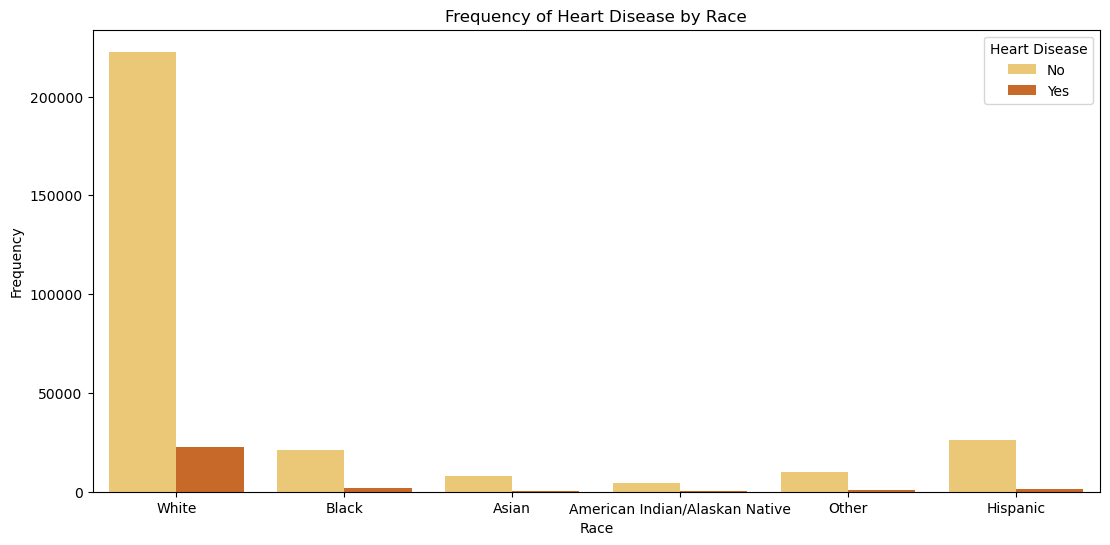

In [30]:
plt.figure(figsize=(13, 6))

# Refined countplot call
sns.countplot(data=df, x='Race', hue='HeartDisease', palette='YlOrBr')

plt.title('Frequency of Heart Disease by Race')
plt.xlabel('Race')
plt.ylabel('Frequency')

# Adding a title to the legend for better clarity
plt.legend(title='Heart Disease', labels=['No', 'Yes'])

plt.show()

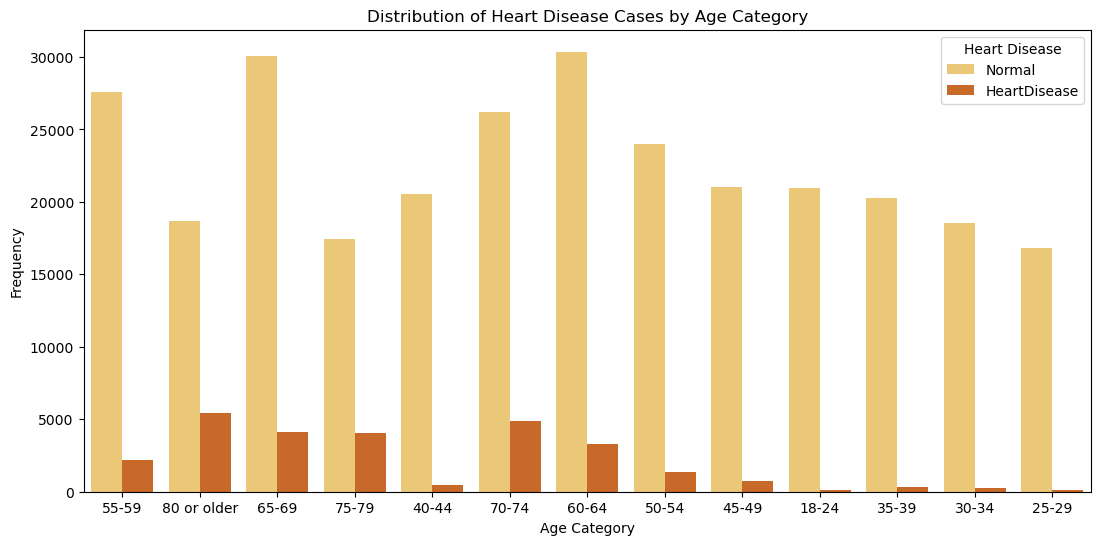

In [31]:
plt.figure(figsize=(13, 6))

# Refined countplot: passing column names directly as strings to 'x' and 'hue'
sns.countplot(data=df, x='AgeCategory', hue='HeartDisease', palette='YlOrBr')

# Using plt.title for a more robust notebook execution
plt.title("Distribution of Heart Disease Cases by Age Category")
plt.xlabel('Age Category')
plt.ylabel('Frequency')

# Ensuring the legend is clear and accurately labeled
plt.legend(title='Heart Disease', labels=['Normal', 'HeartDisease'])

plt.show()

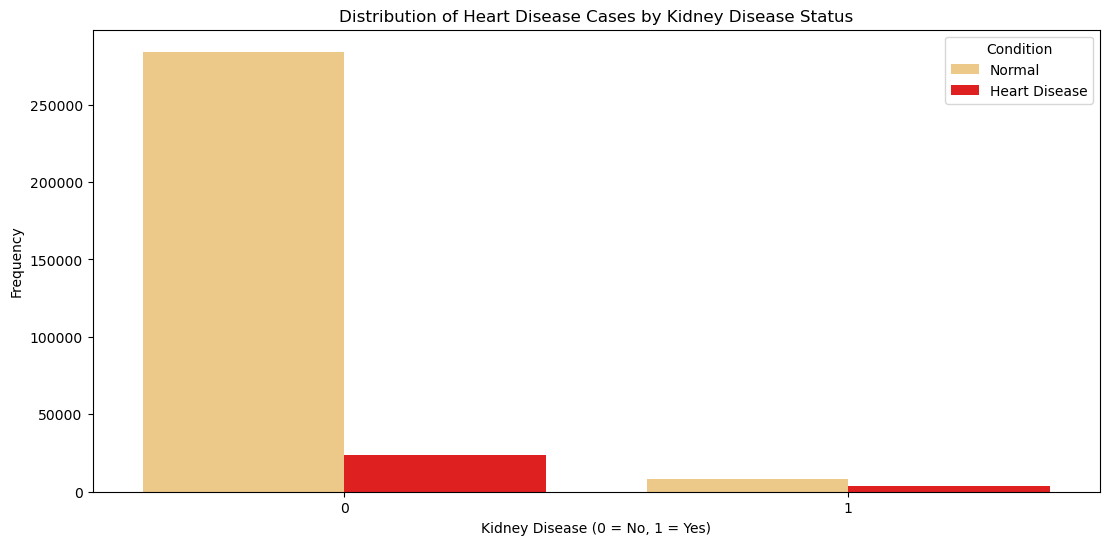

In [32]:
# Set the figure size
plt.figure(figsize=(13, 6))

# Use countplot for categorical data comparison
sns.countplot(data=df, x='KidneyDisease', hue='HeartDisease', palette=['#fccc79', 'red'])

# Add labels and title
plt.xlabel("Kidney Disease (0 = No, 1 = Yes)")
plt.ylabel("Frequency")
plt.title("Distribution of Heart Disease Cases by Kidney Disease Status")

# Add a clear legend
plt.legend(title='Condition', labels=['Normal', 'Heart Disease'])

plt.show()

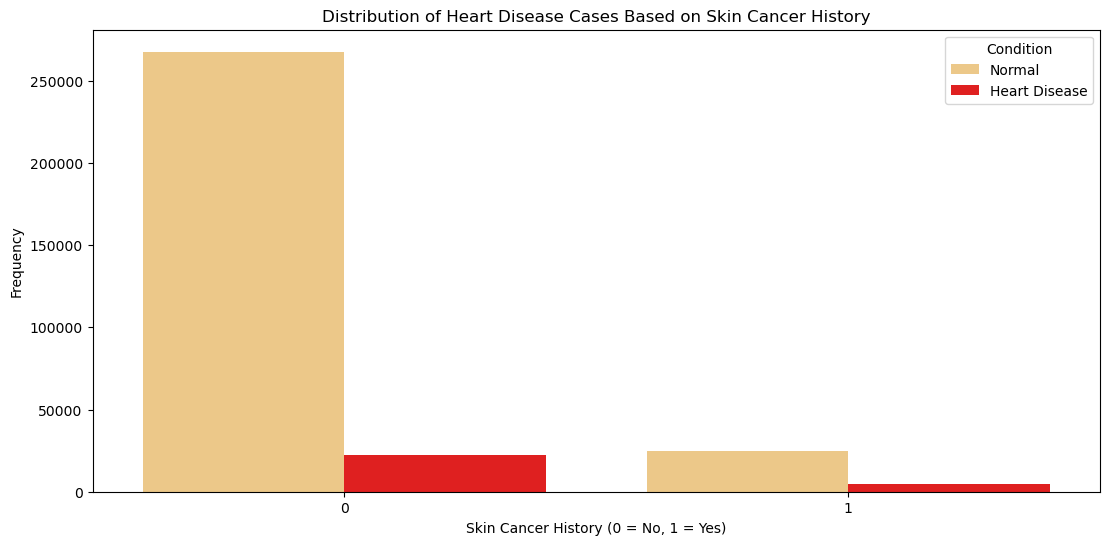

In [33]:
# Set the figure size
plt.figure(figsize=(13, 6))

# Use countplot for categorical comparison
# data=df refers to the heart disease dataframe
sns.countplot(data=df, x='SkinCancer', hue='HeartDisease', palette=['#fccc79', 'red'])

# Add labels and title
plt.xlabel("Skin Cancer History (0 = No, 1 = Yes)")
plt.ylabel("Frequency")
plt.title("Distribution of Heart Disease Cases Based on Skin Cancer History")

# Add a clear legend
plt.legend(title='Condition', labels=['Normal', 'Heart Disease'])

plt.show()

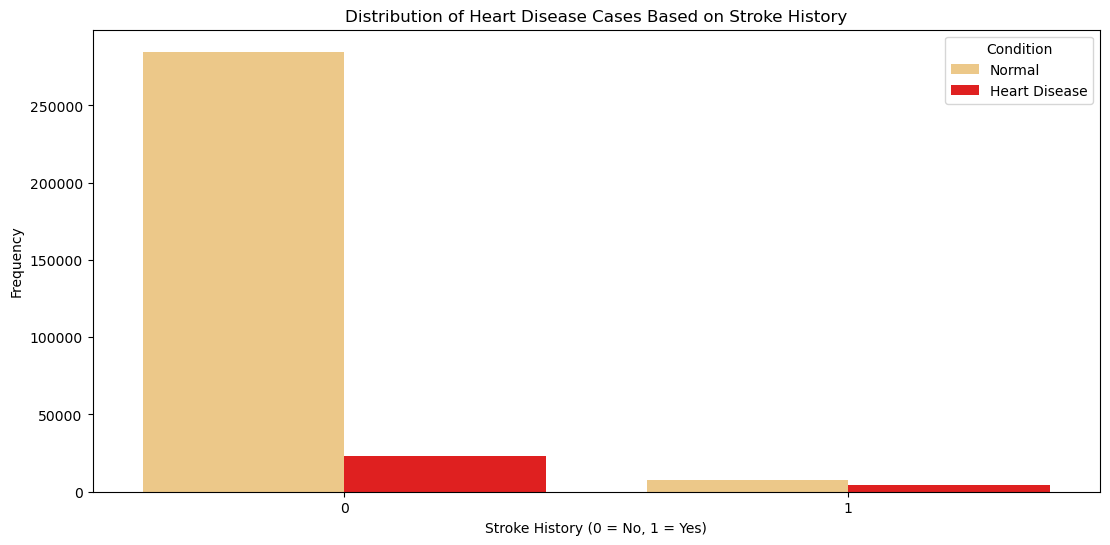

In [34]:
# Set the figure size
plt.figure(figsize=(13, 6))

# Use countplot for categorical comparison between Stroke and HeartDisease
# This clearly shows the frequency without the gaps created by histogram bins
sns.countplot(data=df, x='Stroke', hue='HeartDisease', palette=['#fccc79', 'red'])

# Add labels and title
plt.xlabel("Stroke History (0 = No, 1 = Yes)")
plt.ylabel("Frequency")
plt.title("Distribution of Heart Disease Cases Based on Stroke History")

# Add a clear legend
plt.legend(title='Condition', labels=['Normal', 'Heart Disease'])

plt.show()

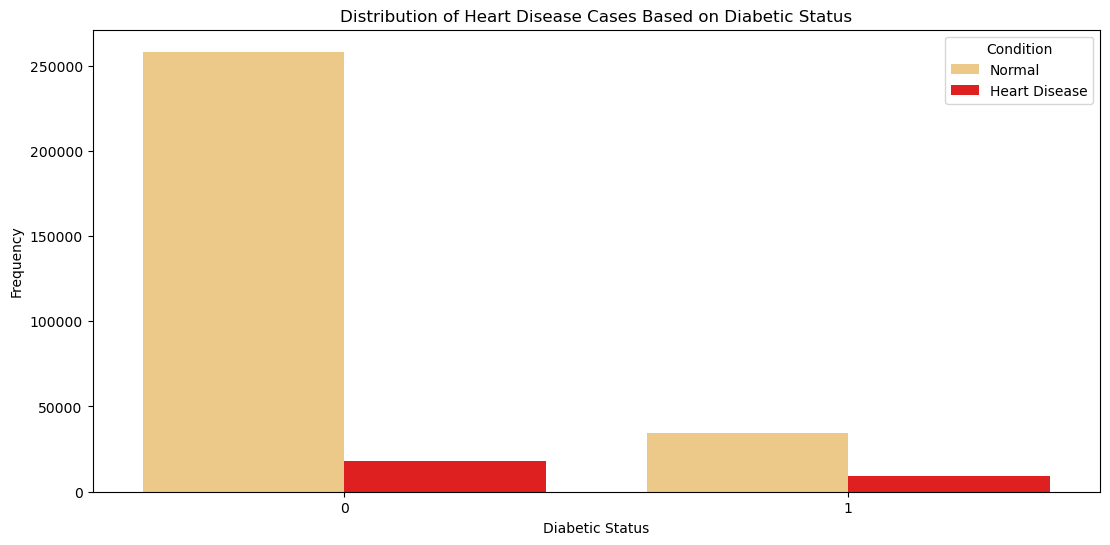

In [35]:
# Set the figure size
plt.figure(figsize=(13, 6))

# Use countplot for categorical comparison between Diabetic and HeartDisease
# This clearly groups the categories (Yes, No, Borderline, etc.)
sns.countplot(data=df, x='Diabetic', hue='HeartDisease', palette=['#fccc79', 'red'])

# Add labels and title
plt.xlabel("Diabetic Status")
plt.ylabel("Frequency")
plt.title("Distribution of Heart Disease Cases Based on Diabetic Status")

# Add a clear legend
plt.legend(title='Condition', labels=['Normal', 'Heart Disease'])

plt.show()

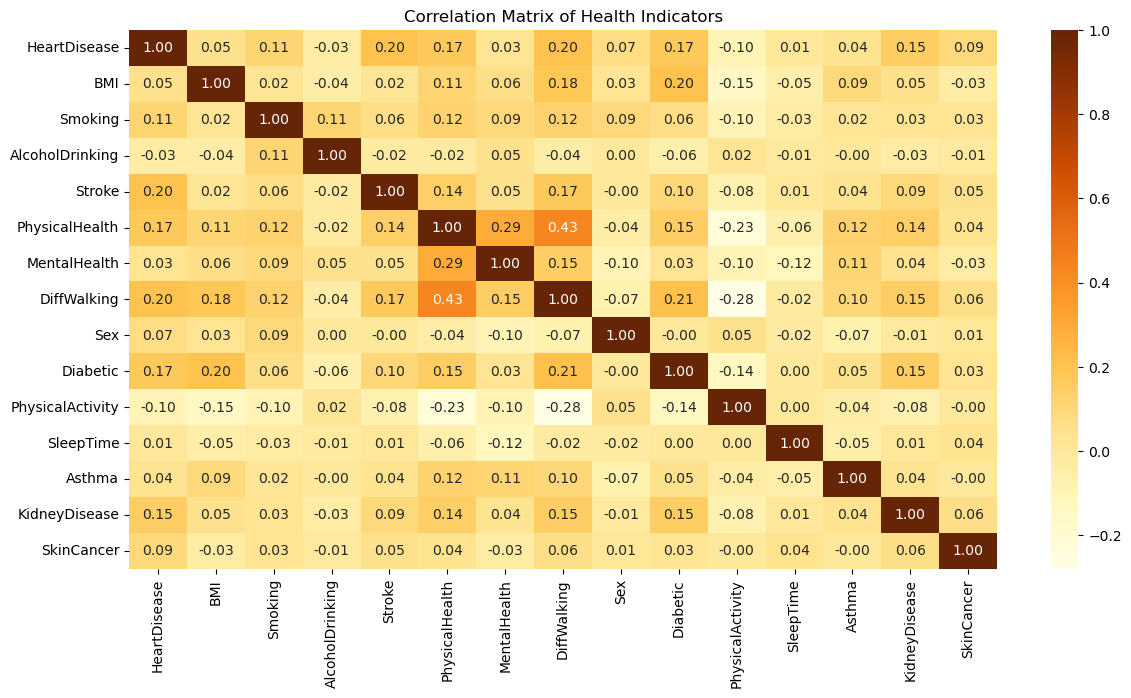

In [42]:
# Ensuring to only calculate correlation for numeric columns
numeric_df = df.select_dtypes(include=['number'])
correlation = numeric_df.corr().round(2)

plt.figure(figsize=(14, 7))

# Plotting the heatmap with annotations and a clear color map
sns.heatmap(correlation, annot=True, cmap='YlOrBr', fmt='.2f')

plt.title("Correlation Matrix of Health Indicators")
plt.show()

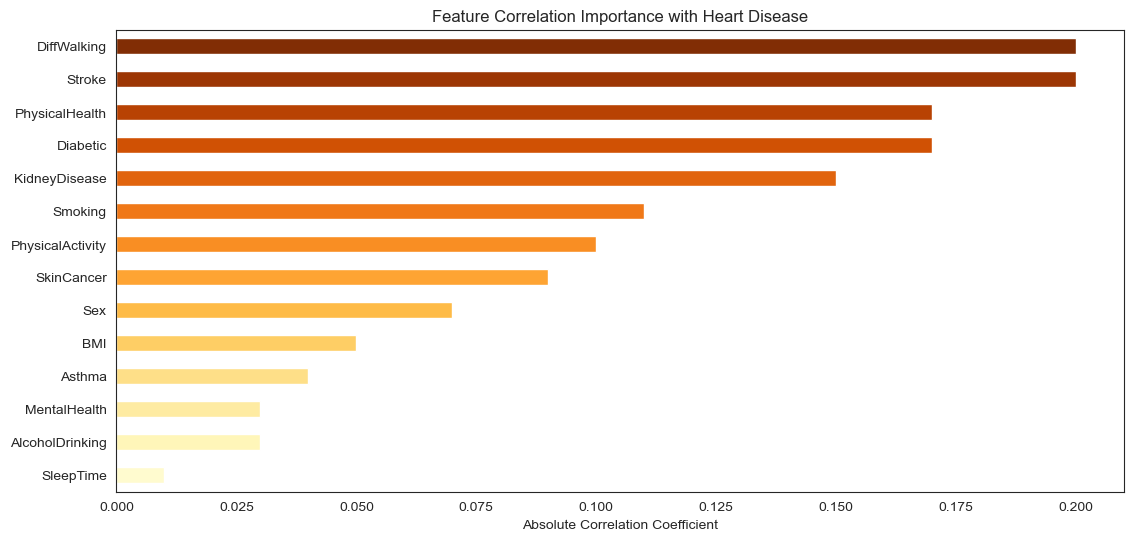

In [43]:
sns.set_style('white')
plt.figure(figsize=(13, 6))

# Calculating absolute correlation with the target variable
# Sort and exclude the target itself (the last one)
abs_corr = abs(correlation['HeartDisease']).sort_values()[:-1]

# Plotting with the YlOrBr palette
abs_corr.plot.barh(color=sns.color_palette('YlOrBr', len(abs_corr)))

plt.title('Feature Correlation Importance with Heart Disease')
plt.xlabel('Absolute Correlation Coefficient')
plt.show()

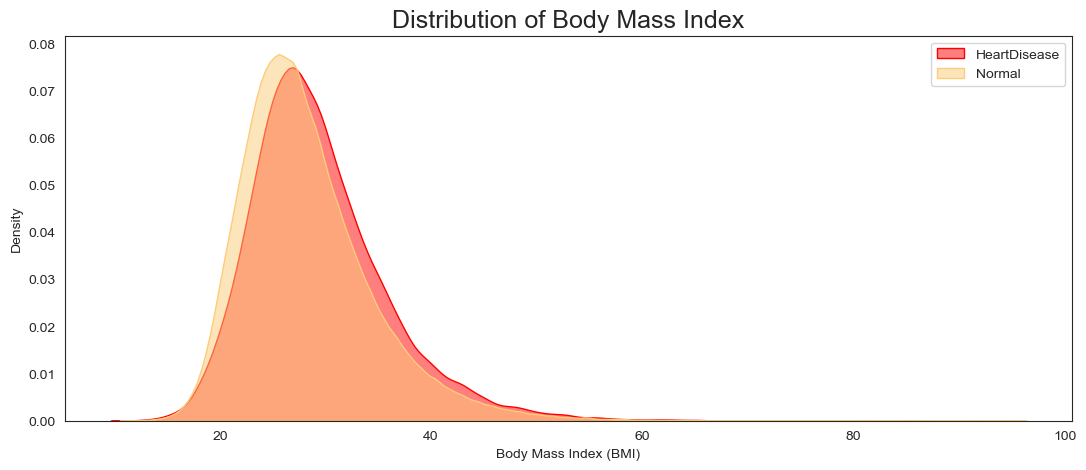

In [44]:
# Set up the figure and axis
fig, ax = plt.subplots(figsize=(13, 5))

# Plotting KDE for HeartDisease cases vs. Normal cases
# Changed 'shade' to 'fill' to avoid deprecation warnings
sns.kdeplot(data=df[df["HeartDisease"]==1], x="BMI", alpha=0.5, fill=True, color="red", label="HeartDisease", ax=ax)
sns.kdeplot(data=df[df["HeartDisease"]==0], x="BMI", alpha=0.5, fill=True, color="#fccc79", label="Normal", ax=ax)

# Styling and labels
plt.title('Distribution of Body Mass Index', fontsize=18)
ax.set_xlabel("Body Mass Index (BMI)")
ax.set_ylabel("Density")
ax.legend()

plt.show()

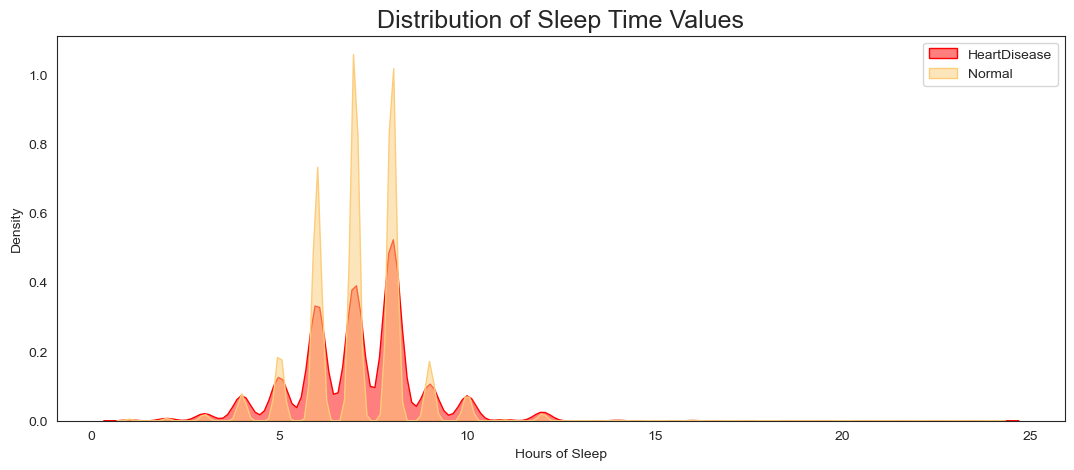

In [45]:
# Set up the figure and axis
fig, ax = plt.subplots(figsize=(13, 5))

# Plotting KDE for HeartDisease cases vs. Normal cases
# Updated 'shade' to 'fill' for future compatibility
sns.kdeplot(data=df[df["HeartDisease"]==1], x="SleepTime", alpha=0.5, fill=True, color="red", label="HeartDisease", ax=ax)
sns.kdeplot(data=df[df["HeartDisease"]==0], x="SleepTime", alpha=0.5, fill=True, color="#fccc79", label="Normal", ax=ax)

# Styling and labels
plt.title('Distribution of Sleep Time Values', fontsize=18)
ax.set_xlabel("Hours of Sleep")
ax.set_ylabel("Density")
ax.legend()

plt.show()

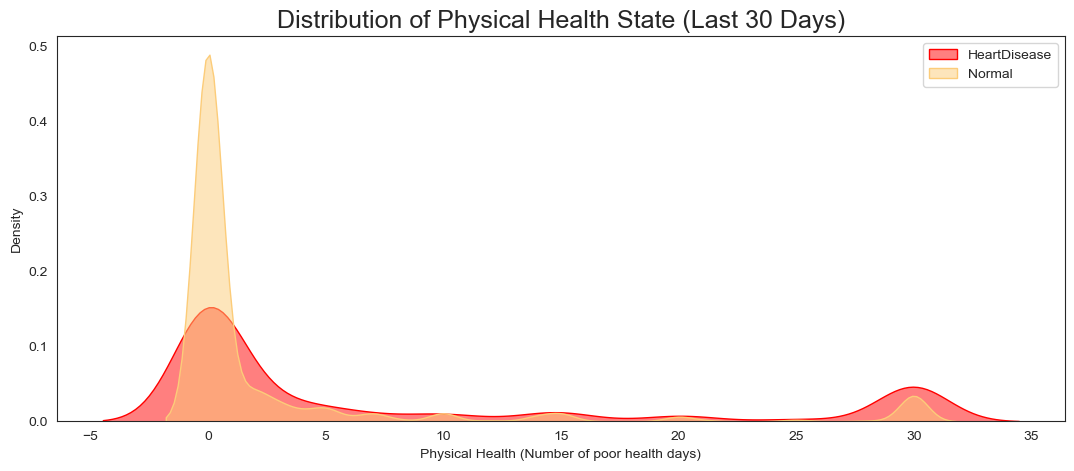

In [46]:
# Set up the figure and axis
fig, ax = plt.subplots(figsize=(13, 5))

# Plotting KDE for HeartDisease cases vs. Normal cases
# Updated 'shade' to 'fill' for compatibility
sns.kdeplot(data=df[df["HeartDisease"]==1], x="PhysicalHealth", alpha=0.5, fill=True, color="red", label="HeartDisease", ax=ax)
sns.kdeplot(data=df[df["HeartDisease"]==0], x="PhysicalHealth", alpha=0.5, fill=True, color="#fccc79", label="Normal", ax=ax)

# Styling and labels
plt.title('Distribution of Physical Health State (Last 30 Days)', fontsize=18)
ax.set_xlabel("Physical Health (Number of poor health days)")
ax.set_ylabel("Density")
ax.legend()

plt.show()

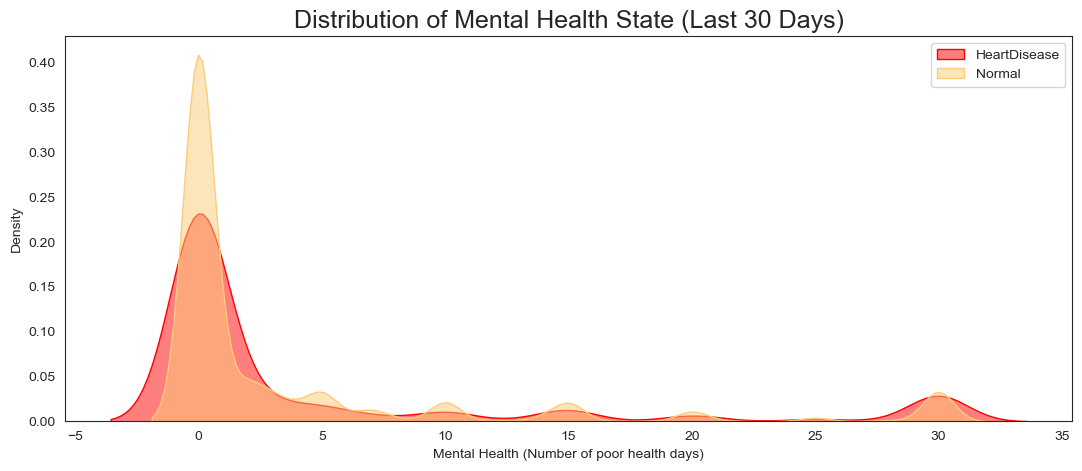

In [47]:
# Set up the figure and axis
fig, ax = plt.subplots(figsize=(13, 5))

# Plotting KDE for HeartDisease cases vs. Normal cases
# fill=True is the modern replacement for shade=True
sns.kdeplot(data=df[df["HeartDisease"]==1], x="MentalHealth", alpha=0.5, fill=True, color="red", label="HeartDisease", ax=ax)
sns.kdeplot(data=df[df["HeartDisease"]==0], x="MentalHealth", alpha=0.5, fill=True, color="#fccc79", label="Normal", ax=ax)

# Styling and labels
plt.title('Distribution of Mental Health State (Last 30 Days)', fontsize=18)
ax.set_xlabel("Mental Health (Number of poor health days)")
ax.set_ylabel("Density")
ax.legend()

plt.show()

In [48]:
#Split dataset for training and testing
#Select Features
features = df.drop(columns =['HeartDisease'], axis = 1)

#Select Target 
target = df['HeartDisease']

# Set Training and Testing Data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, target, shuffle = True, test_size = .2, random_state = 44)


print('Shape of training feature:', X_train.shape)
print('Shape of testing feature:', X_test.shape)
print('Shape of training label:', y_train.shape)
print('Shape of training label:', y_test.shape)

Shape of training feature: (255836, 17)
Shape of testing feature: (63959, 17)
Shape of training label: (255836,)
Shape of training label: (63959,)


In [50]:
# Encoding
transformer = make_column_transformer(
    (OneHotEncoder(sparse_output=False), ['AgeCategory', 'Race', 'GenHealth']),  # Changed sparse=False to sparse_output=False
    remainder='passthrough')

# Encode training data 
transformed_train = transformer.fit_transform(X_train)
transformed_train_data = pd.DataFrame(transformed_train, columns=transformer.get_feature_names_out())  # Changed get_feature_names() to get_feature_names_out()

# Concat the two tables
transformed_train_data.reset_index(drop=True, inplace=True)
X_train.reset_index(drop=True, inplace=True)
X_train = pd.concat([transformed_train_data, X_train], axis=1)

# Remove old columns
X_train.drop(['AgeCategory', 'Race', 'GenHealth'], axis = 1, inplace = True)

# Encode test data 
transformed_test = transformer.transform(X_test)  # Changed fit_transform to transform to use already fitted transformer
transformed_test_data = pd.DataFrame(transformed_test, columns=transformer.get_feature_names_out())  # Changed get_feature_names() to get_feature_names_out()

# Concat the two tables
transformed_test_data.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
X_test = pd.concat([transformed_test_data, X_test], axis=1)

# Remove old columns
X_test.drop(['AgeCategory', 'Race', 'GenHealth'], axis = 1, inplace = True)

In [51]:
# Standardization
scaler = StandardScaler()

# Scale trainint data
X_train = scaler.fit_transform(X_train)

# Scale test data
X_test = scaler.fit_transform(X_test)

In [52]:
def evaluate_model(model, x_test, y_test):
    from sklearn import metrics

    # Predict Test Data 
    y_pred = model.predict(x_test)

    # Calculate accuracy, precision, recall, f1-score, and kappa score
    acc = metrics.accuracy_score(y_test, y_pred)
    prec = metrics.precision_score(y_test, y_pred)
    rec = metrics.recall_score(y_test, y_pred)
    f1 = metrics.f1_score(y_test, y_pred)
    kappa = metrics.cohen_kappa_score(y_test, y_pred)

    # Calculate area under curve (AUC)
    y_pred_proba = model.predict_proba(x_test)[::,1]
    fpr, tpr, _ = metrics.roc_curve(y_test, y_pred_proba)
    auc = metrics.roc_auc_score(y_test, y_pred_proba)

     # Display confussion matrix
    cm = metrics.confusion_matrix(y_test, y_pred)

    return {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'kappa': kappa, 
            'fpr': fpr, 'tpr': tpr, 'auc': auc, 'cm': cm}


In [53]:
# building model
X_train

array([[-0.26549634, -0.23664263, -0.25032481, ..., -0.39281938,
        -0.19512091, -0.32147374],
       [-0.26549634, -0.23664263, -0.25032481, ..., -0.39281938,
        -0.19512091, -0.32147374],
       [-0.26549634, -0.23664263, -0.25032481, ..., -0.39281938,
        -0.19512091, -0.32147374],
       ...,
       [-0.26549634, -0.23664263, -0.25032481, ..., -0.39281938,
        -0.19512091, -0.32147374],
       [-0.26549634, -0.23664263, -0.25032481, ...,  2.54569927,
        -0.19512091, -0.32147374],
       [-0.26549634,  4.22578124, -0.25032481, ..., -0.39281938,
        -0.19512091, -0.32147374]])

In [54]:
# Building a neighbor through kneighbor classifier 
# Building a model using KNeighborsClassifier 
knn = KNeighborsClassifier(n_neighbors = 5)

knn.fit(X_train, y_train)


# Evaluate Model
knn_eval = evaluate_model(knn, X_test, y_test)

# Print result
print('Accuracy:', knn_eval['acc'])
print('Precision:', knn_eval['prec'])
print('Recall:', knn_eval['rec'])
print('F1 Score:', knn_eval['f1'])
print('Cohens Kappa Score:', knn_eval['kappa'])
print('Area Under Curve:', knn_eval['auc'])
print('Confusion Matrix:\n', knn_eval['cm'])

Accuracy: 0.9050016416766992
Precision: 0.3570780399274047
Recall: 0.14450973191333089
F1 Score: 0.2057516339869281
Cohens Kappa Score: 0.16477268538693723
Area Under Curve: 0.7190876830488478
Confusion Matrix:
 [[57096  1417]
 [ 4659   787]]


In [55]:
# Building Decision Tree model 
clf = tree.DecisionTreeClassifier(random_state=0)
clf.fit(X_train, y_train)

# Evaluate Model
clf_eval = evaluate_model(clf, X_test, y_test)

# Print result
print('Accuracy:', clf_eval['acc'])
print('Precision:', clf_eval['prec'])
print('Recall:', clf_eval['rec'])
print('F1 Score:', clf_eval['f1'])
print('Cohens Kappa Score:', clf_eval['kappa'])
print('Area Under Curve:', clf_eval['auc'])
print('Confusion Matrix:\n', clf_eval['cm'])# Evaluate Model

Accuracy: 0.8646945699588799
Precision: 0.232220367278798
Recall: 0.25541681968417185
F1 Score: 0.24326687653025533
Cohens Kappa Score: 0.1691567154170338
Area Under Curve: 0.589573855978808
Confusion Matrix:
 [[53914  4599]
 [ 4055  1391]]


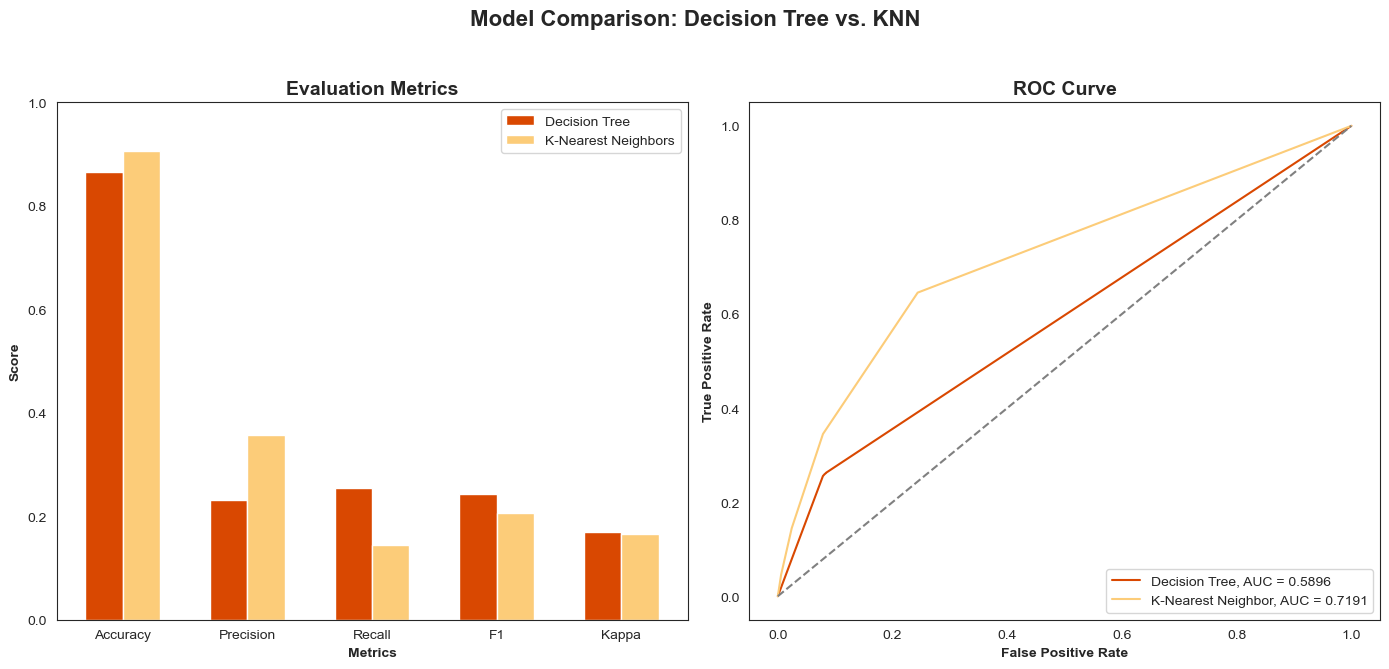

In [57]:
# Initialize figure with two plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Model Comparison: Decision Tree vs. KNN', fontsize=16, fontweight='bold')
fig.set_facecolor('white')

# --- First Plot: Evaluation Metrics ---
barWidth = 0.3
clf_score = [clf_eval['acc'], clf_eval['prec'], clf_eval['rec'], clf_eval['f1'], clf_eval['kappa']]
knn_score = [knn_eval['acc'], knn_eval['prec'], knn_eval['rec'], knn_eval['f1'], knn_eval['kappa']]

r1 = np.arange(len(clf_score))
r2 = [x + barWidth for x in r1]

# Using your preferred YlOrBr-style colors
ax1.bar(r1, clf_score, width=barWidth, color='#d94801', edgecolor='white', label='Decision Tree')
ax1.bar(r2, knn_score, width=barWidth, color='#fccc79', edgecolor='white', label='K-Nearest Neighbors')

ax1.set_xlabel('Metrics', fontweight='bold')
ax1.set_ylabel('Score', fontweight='bold')
ax1.set_xticks([r + (barWidth / 2) for r in range(len(clf_score))])
ax1.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1', 'Kappa'])
ax1.set_ylim(0, 1)
ax1.set_title('Evaluation Metrics', fontsize=14, fontweight='bold')
ax1.legend()

# --- Second Plot: ROC Curve ---
ax2.plot(clf_eval['fpr'], clf_eval['tpr'], color='#d94801', label='Decision Tree, AUC = {:0.4f}'.format(clf_eval['auc']))
ax2.plot(knn_eval['fpr'], knn_eval['tpr'], color='#fccc79', label='K-Nearest Neighbor, AUC = {:0.4f}'.format(knn_eval['auc']))

# Baseline 45-degree line
ax2.plot([0, 1], [0, 1], color='gray', linestyle='--')

ax2.set_xlabel('False Positive Rate', fontweight='bold')
ax2.set_ylabel('True Positive Rate', fontweight='bold')
ax2.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()